<a href="https://colab.research.google.com/github/tanishka-trivedi/PRML-assignments/blob/main/Assignment03_soln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> PRML Assignment-03</h1>

<p> Name: Tanishka Neeraj Trivedi</p>
<p>Roll no.: B24EE1080</p>

### Part-A:-

<h4>Multi-layer Perceptron (from scratch)</h4>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Uploading Dataset

data=pd.read_csv("xor.csv")
X=data.iloc[:, 0:2].values
y=data.iloc[:, 2].values.reshape(-1, 1)
print(data.head())
print("Dataset:")
print(X)
print(y)
X = np.array(X, dtype=float)
y = np.array(y, dtype=float)

   X  Y  Z
0  0  0  0
1  0  1  1
2  1  1  0
3  1  1  0
4  0  0  0
Dataset:
[[0 0]
 [0 1]
 [1 1]
 ...
 [1 1]
 [1 1]
 [1 1]]
[[0]
 [1]
 [0]
 ...
 [0]
 [0]
 [0]]


<p>1. Implement a single neuron.</p>

<p>a- Write a function for perceptron with inputs as weights, bias and
input vector and output as predicted value.</p>

<p>b- Implement the following: (i) weighted sum computation (ii)
Activation function</p>

In [ ]:
#Activation function (sigmoid)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Perceptron func
def perceptron(x, w, b):
    z = np.dot(x, w) + b   #Weighted sum
    y_hat = sigmoid(z)     #Activation
    return y_hat

<p> Weighted sum computes how imp is eahc feature while activation tells whether or not neuron pass</p>

<p>2. Implement a loss function such as mean squared error (MSE)</p>

In [ ]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

<p>Measures how wrong your prediction is
and squaring punishes large errors more</p>

<p>3. Using the perceptron function as building block<p>
<p>a. Create a network with: (i) input layer (2 neurons) (ii) hidden layer
(2-3 neurons) (iii) output layer (1 neuron)</p>
<p>b. Use activation function</p>
<p>c. Implement forward propagation</p>

Input: 2 neurons<br>
Hidden: 2 neurons (minimum for XOR!)<br>
Output: 1 neuron

In [ ]:
np.random.seed(42)

# Input → Hidden
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

# Hidden → Output
W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

In [ ]:
def forward(X, W1, b1, W2, b2):
    # Hidden layer
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    # Output layer
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

<p>Note: hidden layer learns non linearity without which XOR is not possible</p>

<p> 4. Backpropagation</p>
<p>a. Compute gradients manually</p>
<p>b. Update weights using gradient descent</p>
<p>c. Train the MLP on XOR dataset</p>

In [ ]:
#derivative of sigmoid
def sigmoid_derivative(a):
    return a * (1 - a)

In [ ]:
#Backpropagation
def backward(X, y, z1, a1, z2, a2, W2):
    m = X.shape[0]

    # Output layer error
    dz2 = (a2 - y) * sigmoid_derivative(a2)
    dW2 = np.dot(a1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    # Hidden layer error
    dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [ ]:
def forward(X, W1, b1, W2, b2):
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

In [ ]:
#Training (Gradient Descent)
learning_rate = 0.5
epochs = 10000

losses = []

for epoch in range(epochs):
    # Forward
    z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)

    # Loss
    loss = mse_loss(y, a2)
    losses.append(loss)

    # Backward
    dW1, db1, dW2, db2 = backward(X, y, z1, a1, z2, a2, W2)

    # Update weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.25636636371007526
Epoch 1000, Loss: 0.24876562175592917
Epoch 2000, Loss: 0.232318611856513
Epoch 3000, Loss: 0.16259726471775562
Epoch 4000, Loss: 0.13988377026581358
Epoch 5000, Loss: 0.13378507078330398
Epoch 6000, Loss: 0.1312402636984986
Epoch 7000, Loss: 0.12988393603202422
Epoch 8000, Loss: 0.12905146321382002
Epoch 9000, Loss: 0.12849214841771722


<p>Note:Output error → flows backward</p>
<p>Each layer adjusts weights to reduce error</p>

<p>5. EVALUATION</p>

<p>a. Show prediction before and after training</p>
<p>b. Show loss trend over epochs and plot loss vs epochs</p>

In [ ]:
print("Before Training Predictions:")

_, _, _, pred_before = forward(X, W1, b1, W2, b2)
print(np.round(pred_before, 3))

#before training- Since weights are random- wrong outputs as model has learnt them yet

Before Training Predictions:
[[0.046]
 [0.495]
 [0.5  ]
 ...
 [0.5  ]
 [0.5  ]
 [0.5  ]]


In [ ]:
# Predictions after training
_, _, _, predictions = forward(X, W1, b1, W2, b2)

print("Final Predictions:")
print(predictions.round())

Final Predictions:
[[0.]
 [0.]
 [1.]
 ...
 [1.]
 [1.]
 [1.]]


<b><p>Before Training:</p></b>
<p>Weights are random and predictions are incorrect<p>
<b><p>After Training:</p></b>
<p>Model learns XOR pattern and predictions become correct</p>
<br>
<br>
<br>
<p> Therefore, we can say that predictions match XOR output due to leanred weights</p>

<p>Plot Loss</p>

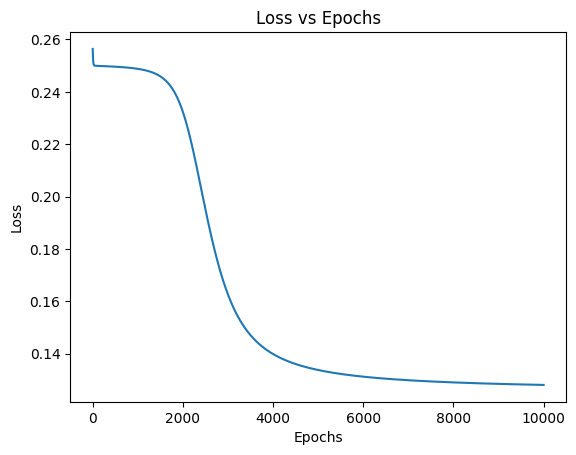

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()

<h6>Why does XOR need MLP?</p>
<p>Since XOR is not linearly separable, single perceptron fails and therfore we need to add hidden layers to create non-linear decision boundary</p>

### Part-B:-

<p>Convolutional Neural Networks (use libraries such as PyTorch)</p>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

<p>1. Load the dataset using PyTorch.<p>
<p>a. Create dataloader for training and testing<br>
b. Visualize few samples</p>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.6MB/s]


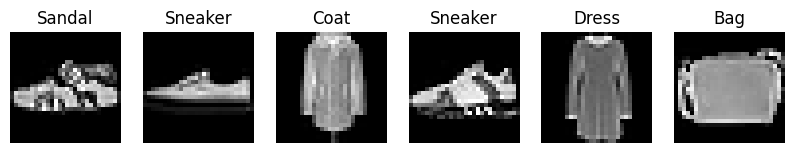

In [ ]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

classes = train_dataset.classes

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.show()

<p>2. Build simple CNN architecture with convolution layers to be equal to 2 along with structures such as ReLU activation function, max-pooling, flatten layer, etc. Use different learning rate techniques such as constant and annealing. Vary the following parameters<br>
a. Filter size: 3x3, 5x5<br>
b. Zero and Same Padding<br>
c. Stride: 1, 2</p>

In [ ]:
class CNN(nn.Module):
    def __init__(self, kernel_size, stride, padding):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(16, 32, kernel_size, stride, padding)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        # Temporary FC (will adjust dynamically)
        self.fc1 = None
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.relu(self.conv2(x))

        x = x.view(x.size(0), -1)


        if self.fc1 is None:
            self.fc1 = nn.Linear(x.shape[1], 128).to(x.device)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

<p>3. Train the CNN architecture with loss for classification.</p>



In [ ]:
def train_model(model, optimizer, scheduler=None, epochs=5):
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        if scheduler:
            scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

<p>4. Evaluate model on test data for different architectures and compare the
performances of each model with respect to different learning rate
techniques.</p>

In [ ]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


<h6>Run Experiments:</h6>

In [ ]:
results = []

kernel_sizes = [3, 5]
strides = [1, 2]
learning_rates = [0.001, 0.01]

for k in kernel_sizes:
    for s in strides:

        # Correct SAME padding dynamically
        same_padding = k // 2

        for padding_type in ["valid", "same"]:
            p = 0 if padding_type == "valid" else same_padding

            for lr in learning_rates:
                print(f"Kernel={k}, Stride={s}, Padding={padding_type}, LR={lr}")

                model = CNN(kernel_size=k, stride=s, padding=p).to(device)

                # Constant LR
                optimizer = optim.Adam(model.parameters(), lr=lr)

                train_model(model, optimizer, epochs=5)
                acc_const = evaluate_model(model)

                print(f"Constant LR Accuracy: {acc_const:.2f}%")

                # LR Annealing (Step Decay)
                model = CNN(kernel_size=k, stride=s, padding=p).to(device)

                optimizer = optim.Adam(model.parameters(), lr=lr)
                scheduler = optim.lr_scheduler.StepLR(
                    optimizer, step_size=2, gamma=0.5)

                train_model(model, optimizer, scheduler, epochs=5)
                acc_anneal = evaluate_model(model)

                print(f"Annealed LR Accuracy: {acc_anneal:.2f}%")

                results.append((k, s, padding_type, lr, acc_const, acc_anneal))



Kernel=3, Stride=1, Padding=valid, LR=0.001
Epoch [1/5], Loss: 648.5424
Epoch [2/5], Loss: 411.9460
Epoch [3/5], Loss: 372.6281
Epoch [4/5], Loss: 348.7245
Epoch [5/5], Loss: 332.4781
Constant LR Accuracy: 87.15%
Epoch [1/5], Loss: 660.7643
Epoch [2/5], Loss: 413.3121
Epoch [3/5], Loss: 370.7688
Epoch [4/5], Loss: 358.7097
Epoch [5/5], Loss: 345.6136
Annealed LR Accuracy: 85.94%
Kernel=3, Stride=1, Padding=valid, LR=0.01
Epoch [1/5], Loss: 475.6653
Epoch [2/5], Loss: 360.9596
Epoch [3/5], Loss: 336.4196
Epoch [4/5], Loss: 323.0785
Epoch [5/5], Loss: 313.4683
Constant LR Accuracy: 86.61%
Epoch [1/5], Loss: 445.9137
Epoch [2/5], Loss: 341.6666
Epoch [3/5], Loss: 297.9380
Epoch [4/5], Loss: 286.0127
Epoch [5/5], Loss: 261.4989
Annealed LR Accuracy: 88.36%
Kernel=3, Stride=1, Padding=same, LR=0.001
Epoch [1/5], Loss: 634.5102
Epoch [2/5], Loss: 391.9064
Epoch [3/5], Loss: 356.5943
Epoch [4/5], Loss: 337.8412
Epoch [5/5], Loss: 323.4763
Constant LR Accuracy: 87.75%
Epoch [1/5], Loss: 656.84

<p>High learning rate causes oscillation around minima, preventing convergence. That is,Higher learning rates resulted in lower accuracy due to unstable training and overshooting of the optimal solution. Lower learning rates provided smoother convergence and better performance.</p>



### Conclusion:


<h4>Part-A:</h4>
<p>This experiment demonstrated the implementation of a Multi-Layer Perceptron (MLP) from scratch without using any deep learning libraries. A single perceptron was first implemented using weighted sum and sigmoid activation, followed by the construction of a neural network with one hidden layer. The XOR problem, being non-linearly separable, highlighted the limitation of a single neuron and justified the need for hidden layers.

Using forward propagation, backpropagation, and gradient descent, the network successfully learned the XOR mapping. The loss decreased over epochs, and predictions improved from random outputs before training to correct outputs after training. This experiment provided a clear understanding of how neural networks learn through error minimization and how hidden layers enable modeling of non-linear relationships.</p>
<br>
<h4>Part-B:</h4>
<p>In this part, a Convolutional Neural Network (CNN) was implemented using PyTorch to classify images from the Fashion MNIST dataset. The model consisted of convolutional layers, ReLU activation, max pooling, and fully connected layers. Data loading and preprocessing were efficiently handled using PyTorch DataLoader.

Different architectural parameters such as kernel size, stride, padding, and learning rate strategies were explored using a grid search approach. The results showed that model performance is highly sensitive to these parameters. Smaller strides and appropriate padding preserved spatial information and improved accuracy, while learning rate scheduling helped achieve better convergence.

Overall, this experiment demonstrated the effectiveness of CNNs in automatically extracting hierarchical features from images and highlighted the importance of hyperparameter tuning in achieving optimal performance.</p>